<a href="https://colab.research.google.com/github/eshan14git/football-qa-nlp/blob/tishan-dev/tishan_nlp_gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 01. Environment Setup

In [ ]:
# Install necessary libraries. We'll use pandas for data manipulation and TensorFlow for the deep learning model.
!pip install pandas tensorflow numpy scikit-learn

## 02. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Embedding, Bidirectional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully!")

Libraries imported successfully!


## 03. Load Football Dataset

In [ ]:
# Load the football datasets
results_df = pd.read_csv('/content/results.csv')
shootouts_df = pd.read_csv('/content/shootouts.csv')
goalscorers_df = pd.read_csv('/content/goalscorers.csv')
former_names_df = pd.read_csv('/content/former_names.csv')

print("Datasets loaded successfully!")

# Display the first few rows of each DataFrame to get an overview
print("\nResults DataFrame Head:")
display(results_df.head())

print("\nShootouts DataFrame Head:")
display(shootouts_df.head())

print("\nGoalscorers DataFrame Head:")
display(goalscorers_df.head())

print("\nFormer Names DataFrame Head:")
display(former_names_df.head())

Datasets loaded successfully!

Results DataFrame Head:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False



Shootouts DataFrame Head:


,date,home_team,away_team,winner,first_shooter
0,8/22/1967,India,Taiwan,Taiwan,NaN
1,11/14/1971,South Korea,Vietnam Republic,South Korea,NaN
2,5/7/1972,South Korea,Iraq,Iraq,NaN
3,5/17/1972,Thailand,South Korea,South Korea,NaN
4,5/19/1972,Thailand,Cambodia,Thailand,NaN



Goalscorers DataFrame Head:


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,7/2/1916,Chile,Uruguay,Uruguay,José Piendibene,44,False,False
1,7/2/1916,Chile,Uruguay,Uruguay,Isabelino Gradín,55,False,False
2,7/2/1916,Chile,Uruguay,Uruguay,Isabelino Gradín,70,False,False
3,7/2/1916,Chile,Uruguay,Uruguay,José Piendibene,75,False,False
4,7/6/1916,Argentina,Chile,Argentina,Alberto Ohaco,2,False,False



Former Names DataFrame Head:


,current,former,start_date,end_date
0,Benin,Dahomey,11/8/1959,11/30/1975
1,Burkina Faso,Upper Volta,4/14/1960,8/4/1984
2,Curaçao,Netherlands Antilles,3/3/1957,10/10/2010
3,Czechoslovakia,Bohemia,4/5/1903,1/1/1919
4,Czechoslovakia,Bohemia and Moravia,1/1/1939,5/1/1945


## 04. Understand Dataset

### 4.1 Display first records

In [ ]:
print("Results DataFrame Head:")
display(results_df.head())
print("\nShootouts DataFrame Head:")
display(shootouts_df.head())
print("\nGoalscorers DataFrame Head:")
display(goalscorers_df.head())
print("\nFormer Names DataFrame Head:")
display(former_names_df.head())

Results DataFrame Head:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False



Shootouts DataFrame Head:


,date,home_team,away_team,winner,first_shooter
0,8/22/1967,India,Taiwan,Taiwan,NaN
1,11/14/1971,South Korea,Vietnam Republic,South Korea,NaN
2,5/7/1972,South Korea,Iraq,Iraq,NaN
3,5/17/1972,Thailand,South Korea,South Korea,NaN
4,5/19/1972,Thailand,Cambodia,Thailand,NaN



Goalscorers DataFrame Head:


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,7/2/1916,Chile,Uruguay,Uruguay,José Piendibene,44,False,False
1,7/2/1916,Chile,Uruguay,Uruguay,Isabelino Gradín,55,False,False
2,7/2/1916,Chile,Uruguay,Uruguay,Isabelino Gradín,70,False,False
3,7/2/1916,Chile,Uruguay,Uruguay,José Piendibene,75,False,False
4,7/6/1916,Argentina,Chile,Argentina,Alberto Ohaco,2,False,False



Former Names DataFrame Head:


,current,former,start_date,end_date
0,Benin,Dahomey,11/8/1959,11/30/1975
1,Burkina Faso,Upper Volta,4/14/1960,8/4/1984
2,Curaçao,Netherlands Antilles,3/3/1957,10/10/2010
3,Czechoslovakia,Bohemia,4/5/1903,1/1/1919
4,Czechoslovakia,Bohemia and Moravia,1/1/1939,5/1/1945


### 4.2 Check shape

In [ ]:
print(f"Results DataFrame shape: {results_df.shape}")
print(f"Shootouts DataFrame shape: {shootouts_df.shape}")
print(f"Goalscorers DataFrame shape: {goalscorers_df.shape}")
print(f"Former Names DataFrame shape: {former_names_df.shape}")

Results DataFrame shape: (49485, 9)
Shootouts DataFrame shape: (682, 5)
Goalscorers DataFrame shape: (47855, 8)
Former Names DataFrame shape: (36, 4)


### 4.3 Check columns

In [ ]:
print("Results DataFrame columns: ", results_df.columns.tolist())
print("Shootouts DataFrame columns: ", shootouts_df.columns.tolist())
print("Goalscorers DataFrame columns: ", goalscorers_df.columns.tolist())
print("Former Names DataFrame columns: ", former_names_df.columns.tolist())

Results DataFrame columns:  ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
Shootouts DataFrame columns:  ['date', 'home_team', 'away_team', 'winner', 'first_shooter']
Goalscorers DataFrame columns:  ['date', 'home_team', 'away_team', 'team', 'scorer', 'minute', 'own_goal', 'penalty']
Former Names DataFrame columns:  ['current', 'former', 'start_date', 'end_date']


### 4.4 Check data types

In [ ]:
print("Results DataFrame Dtypes:\n", results_df.dtypes)
print("\nShootouts DataFrame Dtypes:\n", shootouts_df.dtypes)
print("\nGoalscorers DataFrame Dtypes:\n", goalscorers_df.dtypes)
print("\nFormer Names DataFrame Dtypes:\n", former_names_df.dtypes)

Results DataFrame Dtypes:
 date          object
home_team     object
away_team     object
home_score     int64
away_score     int64
tournament    object
city          object
country       object
neutral         bool
dtype: object

Shootouts DataFrame Dtypes:
 date             object
home_team        object
away_team        object
winner           object
first_shooter    object
dtype: object

Goalscorers DataFrame Dtypes:
 date         object
home_team    object
away_team    object
team         object
scorer       object
minute       object
own_goal       bool
penalty        bool
dtype: object

Former Names DataFrame Dtypes:
 current       object
former        object
start_date    object
end_date      object
dtype: object


### 4.5 Check missing values

In [ ]:
print("Results DataFrame Missing Values:\n", results_df.isnull().sum())
print("\nShootouts DataFrame Missing Values:\n", shootouts_df.isnull().sum())
print("\nGoalscorers DataFrame Missing Values:\n", goalscorers_df.isnull().sum())
print("\nFormer Names DataFrame Missing Values:\n", former_names_df.isnull().sum())

Results DataFrame Missing Values:
 date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

Shootouts DataFrame Missing Values:
 date               0
home_team          0
away_team          0
winner             0
first_shooter    422
dtype: int64

Goalscorers DataFrame Missing Values:
 date           0
home_team      0
away_team      0
team           0
scorer        48
minute       256
own_goal       0
penalty        0
dtype: int64

Former Names DataFrame Missing Values:
 current       0
former        0
start_date    0
end_date      0
dtype: int64


## 05. Data Cleaning

### 5.1 Remove duplicates

In [ ]:
print(f"Results DataFrame initial shape: {results_df.shape}")
results_df.drop_duplicates(inplace=True)
print(f"Results DataFrame shape after removing duplicates: {results_df.shape}")

print(f"\nShootouts DataFrame initial shape: {shootouts_df.shape}")
shootouts_df.drop_duplicates(inplace=True)
print(f"Shootouts DataFrame shape after removing duplicates: {shootouts_df.shape}")

print(f"\nGoalscorers DataFrame initial shape: {goalscorers_df.shape}")
goalscorers_df.drop_duplicates(inplace=True)
print(f"Goalscorers DataFrame shape after removing duplicates: {goalscorers_df.shape}")

print(f"\nFormer Names DataFrame initial shape: {former_names_df.shape}")
former_names_df.drop_duplicates(inplace=True)
print(f"Former Names DataFrame shape after removing duplicates: {former_names_df.shape}")

Results DataFrame initial shape: (49485, 9)
Results DataFrame shape after removing duplicates: (49485, 9)

Shootouts DataFrame initial shape: (682, 5)
Shootouts DataFrame shape after removing duplicates: (682, 5)

Goalscorers DataFrame initial shape: (47855, 8)
Goalscorers DataFrame shape after removing duplicates: (47773, 8)

Former Names DataFrame initial shape: (36, 4)
Former Names DataFrame shape after removing duplicates: (36, 4)


### 5.2 Handle missing values

In [ ]:
# For 'results_df', 'city' and 'country' have some missing values. We'll fill them with 'Unknown' for now.
# 'neutral' is boolean, and 'date' columns will be converted.
results_df['city'].fillna('Unknown', inplace=True)
results_df['country'].fillna('Unknown', inplace=True)

# For 'shootouts_df', 'winner' and 'first_shooter' have missing values. 'winner' is critical, 'first_shooter' can be filled with 'Unknown'.
# For simplicity, we'll drop rows where 'winner' is NaN as it's the outcome, and fill 'first_shooter' with 'Unknown'.
shootouts_df.dropna(subset=['winner'], inplace=True)
shootouts_df['first_shooter'].fillna('Unknown', inplace=True)

# For 'goalscorers_df', 'scorer' and 'minute' have some missing values. We'll fill 'scorer' with 'Unknown' and 'minute' with 0.
goalscorers_df['scorer'].fillna('Unknown', inplace=True)
goalscorers_df['minute'].fillna(0, inplace=True) # Assuming 0 if minute is unknown, or could consider median/mean later if needed

# For 'former_names_df', 'start_date' and 'end_date' have some missing values. Fill with a placeholder like 'Unknown'.
former_names_df['start_date'].fillna('Unknown', inplace=True)
former_names_df['end_date'].fillna('Unknown', inplace=True)

# Convert date columns to datetime objects where applicable, using errors='coerce' and format='mixed' for robustness
results_df['date'] = pd.to_datetime(results_df['date'], errors='coerce', format='mixed')
shootouts_df['date'] = pd.to_datetime(shootouts_df['date'], errors='coerce', format='mixed')
goalscorers_df['date'] = pd.to_datetime(goalscorers_df['date'], errors='coerce', format='mixed')

print("Missing values handled and dates converted.")
print("\nResults DataFrame Missing Values After Handling:\n", results_df.isnull().sum())
print("\nShootouts DataFrame Missing Values After Handling:\n", shootouts_df.isnull().sum())
print("\nGoalscorers DataFrame Missing Values After Handling:\n", goalscorers_df.isnull().sum())
print("\nFormer Names DataFrame Missing Values After Handling:\n", former_names_df.isnull().sum())

/tmp/ipykernel_593/2766018607.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  results_df['city'].fillna('Unknown', inplace=True)
/tmp/ipykernel_593/2766018607.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

Missing values handled and dates converted.

Results DataFrame Missing Values After Handling:
 date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

Shootouts DataFrame Missing Values After Handling:
 date             0
home_team        0
away_team        0
winner           0
first_shooter    0
dtype: int64

Goalscorers DataFrame Missing Values After Handling:
 date         0
home_team    0
away_team    0
team         0
scorer       0
minute       0
own_goal     0
penalty      0
dtype: int64

Former Names DataFrame Missing Values After Handling:
 current       0
former        0
start_date    0
end_date      0
dtype: int64


### 5.3 Standardize column names

In [ ]:
def standardize_colnames(df):
    df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
    return df

results_df = standardize_colnames(results_df)
shootouts_df = standardize_colnames(shootouts_df)
goalscorers_df = standardize_colnames(goalscorers_df)
former_names_df = standardize_colnames(former_names_df)

print("Column names standardized.")
print("Results DataFrame columns: ", results_df.columns.tolist())
print("Shootouts DataFrame columns: ", shootouts_df.columns.tolist())
print("Goalscorers DataFrame columns: ", goalscorers_df.columns.tolist())
print("Former Names DataFrame columns: ", former_names_df.columns.tolist())

Column names standardized.
Results DataFrame columns:  ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
Shootouts DataFrame columns:  ['date', 'home_team', 'away_team', 'winner', 'first_shooter']
Goalscorers DataFrame columns:  ['date', 'home_team', 'away_team', 'team', 'scorer', 'minute', 'own_goal', 'penalty']
Former Names DataFrame columns:  ['current', 'former', 'start_date', 'end_date']


### 5.4 Standardize text (e.g., team names, tournament names)

In [ ]:
def standardize_text(text):
    if isinstance(text, str):
        return text.strip().lower() # Convert to lowercase and strip whitespace
    return text

# Apply standardization to relevant string columns in results_df
for col in ['home_team', 'away_team', 'tournament', 'city', 'country']:
    if col in results_df.columns:
        results_df[col] = results_df[col].apply(standardize_text)

# Apply standardization to relevant string columns in shootouts_df
for col in ['home_team', 'away_team', 'winner', 'first_shooter']:
    if col in shootouts_df.columns:
        shootouts_df[col] = shootouts_df[col].apply(standardize_text)

# Apply standardization to relevant string columns in goalscorers_df
for col in ['home_team', 'away_team', 'team', 'scorer']:
    if col in goalscorers_df.columns:
        goalscorers_df[col] = goalscorers_df[col].apply(standardize_text)

# Apply standardization to relevant string columns in former_names_df
for col in ['current', 'former']:
    if col in former_names_df.columns:
        former_names_df[col] = former_names_df[col].apply(standardize_text)

print("Text data standardized in relevant columns.")

display(results_df.head())

Text data standardized in relevant columns.


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,scotland,england,0,0,friendly,glasgow,scotland,False
1,1873-03-08,england,scotland,4,2,friendly,london,england,False
2,1874-03-07,scotland,england,2,1,friendly,glasgow,scotland,False
3,1875-03-06,england,scotland,2,2,friendly,london,england,False
4,1876-03-04,scotland,england,3,0,friendly,glasgow,scotland,False


### 5.5 Validate cleaned dataset

In [ ]:
print("Results DataFrame Info After Cleaning ---")
results_df.info()
print("\nShootouts DataFrame Info After Cleaning ---")
shootouts_df.info()
print("\nGoalscorers DataFrame Info After Cleaning ---")
goalscorers_df.info()
print("\nFormer Names DataFrame Info After Cleaning ---")
former_names_df.info()

print("\nResults DataFrame Missing Values After Cleaning:\n", results_df.isnull().sum())
print("\nShootouts DataFrame Missing Values After Cleaning:\n", shootouts_df.isnull().sum())
print("\nGoalscorers DataFrame Missing Values After Cleaning:\n", goalscorers_df.isnull().sum())
print("\nFormer Names DataFrame Missing Values After Cleaning:\n", former_names_df.isnull().sum())

Results DataFrame Info After Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49485 entries, 0 to 49484
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49485 non-null  object
 1   home_team   49485 non-null  object
 2   away_team   49485 non-null  object
 3   home_score  49485 non-null  int64 
 4   away_score  49485 non-null  int64 
 5   tournament  49485 non-null  object
 6   city        49485 non-null  object
 7   country     49485 non-null  object
 8   neutral     49485 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.1+ MB

Shootouts DataFrame Info After Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           682 non-null    object
 1   home_team      682 non-null    object
 2   away_team      682 non-nu

## 06. Exploratory Data Analysis

### 6.1 Dataset statistics

In [ ]:
print("\n--- Results DataFrame Statistics ---")
display(results_df.describe(include='all'))

print("\n--- Shootouts DataFrame Statistics ---")
display(shootouts_df.describe(include='all'))

print("\n--- Goalscorers DataFrame Statistics ---")
display(goalscorers_df.describe(include='all'))


--- Results DataFrame Statistics ---


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,outcome
count,49485,49485,49485,49485.000000,49485.000000,49485,49485,49485,49485,49485.000000,49485
unique,NaN,327,321,NaN,NaN,200,2089,269,2,NaN,3
top,NaN,brazil,uruguay,NaN,NaN,friendly,kuala lumpur,united states,False,NaN,home_win
freq,NaN,617,585,NaN,NaN,18388,745,1568,36353,NaN,24249
mean,1994-05-24 11:18:25.862382464,NaN,NaN,1.757199,1.182035,NaN,NaN,NaN,NaN,1993.864363,NaN
min,1872-11-30 00:00:00,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,1872.000000,NaN
25%,1980-09-10 00:00:00,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,1980.000000,NaN
50%,2000-07-16 00:00:00,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,2000.000000,NaN
75%,2013-07-16 00:00:00,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,2013.000000,NaN
max,2026-07-19 00:00:00,NaN,NaN,31.000000,21.000000,NaN,NaN,NaN,NaN,2026.000000,NaN



--- Shootouts DataFrame Statistics ---


,date,home_team,away_team,winner,first_shooter
count,682,682,682,682,682
unique,NaN,188,198,183,97
top,NaN,south africa,egypt,egypt,unknown
freq,NaN,18,17,16,422
mean,2004-05-03 08:03:31.143694976,NaN,NaN,NaN,NaN
min,1967-08-22 00:00:00,NaN,NaN,NaN,NaN
25%,1993-02-21 00:00:00,NaN,NaN,NaN,NaN
50%,2004-07-19 12:00:00,NaN,NaN,NaN,NaN
75%,2017-06-30 12:00:00,NaN,NaN,NaN,NaN
max,2026-07-07 00:00:00,NaN,NaN,NaN,NaN



--- Goalscorers DataFrame Statistics ---


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
count,47773,47773,47773,47773,47773,47773,47773,47773
unique,NaN,220,220,220,15360,134,2,2
top,NaN,brazil,uruguay,brazil,cristiano ronaldo,90,False,False
freq,NaN,1054,803,1079,124,2039,46847,44514
mean,1999-06-18 06:38:10.984447232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1916-07-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1989-05-17 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2004-06-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2016-06-21 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2026-07-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 6.2 Match distribution over time

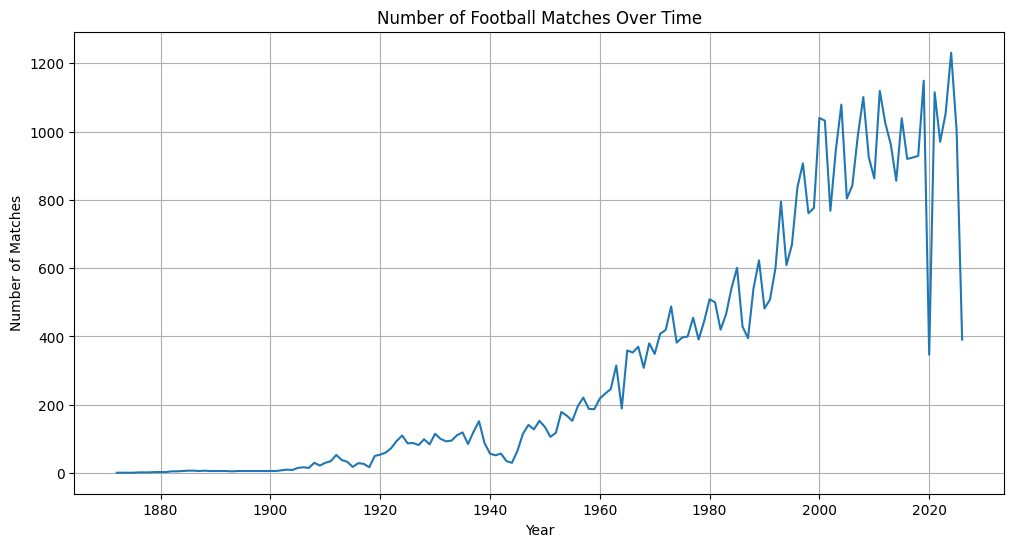

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group matches by year and count them
results_df['year'] = results_df['date'].dt.year
match_counts = results_df.groupby('year').size()

plt.figure(figsize=(12, 6))
match_counts.plot(kind='line')
plt.title('Number of Football Matches Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Matches')
plt.grid(True)
plt.show()

### 6.3 Team frequency


--- Top 20 Most Frequent Teams ---


,count
sweden,1103.0
england,1098.0
argentina,1077.0
brazil,1062.0
germany,1033.0
south korea,1008.0
mexico,1006.0
hungary,1006.0
uruguay,973.0
france,943.0


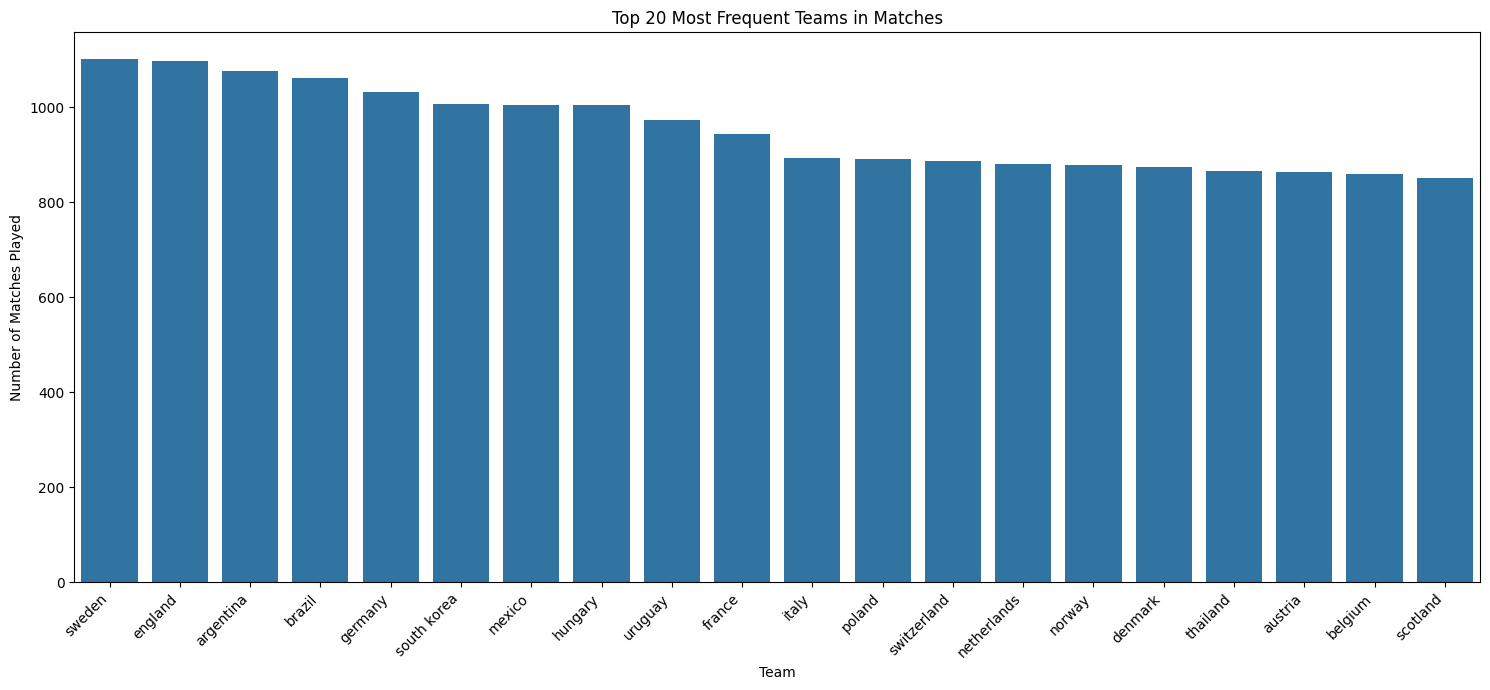

In [ ]:
home_team_counts = results_df['home_team'].value_counts()
away_team_counts = results_df['away_team'].value_counts()

# Combine counts and get top 20 most frequent teams
total_team_counts = home_team_counts.add(away_team_counts, fill_value=0).sort_values(ascending=False)

print("\n--- Top 20 Most Frequent Teams ---")
display(total_team_counts.head(20))

plt.figure(figsize=(15, 7))
sns.barplot(x=total_team_counts.head(20).index, y=total_team_counts.head(20).values)
plt.title('Top 20 Most Frequent Teams in Matches')
plt.xlabel('Team')
plt.ylabel('Number of Matches Played')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.4 Match Outcome Distribution (Target Distribution)


--- Match Outcome Distribution ---
outcome
home_win    0.490027
away_win    0.282570
draw        0.227402
Name: proportion, dtype: float64


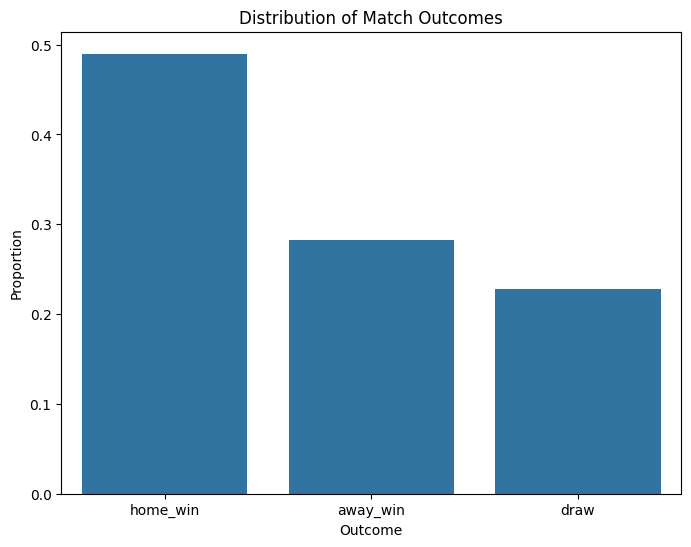

In [ ]:
# First, create the 'outcome' column if it doesn't exist (as per previous plan)
def get_match_outcome(row):
    if row['home_score'] > row['away_score']:
        return 'home_win'  # Home Win
    elif row['home_score'] == row['away_score']:
        return 'draw'  # Draw
    else:
        return 'away_win'  # Away Win

# Only create if the column doesn't exist to avoid re-running if it was already made
if 'outcome' not in results_df.columns:
    results_df['outcome'] = results_df.apply(get_match_outcome, axis=1)

outcome_distribution = results_df['outcome'].value_counts(normalize=True)

print("\n--- Match Outcome Distribution ---")
print(outcome_distribution)

plt.figure(figsize=(8, 6))
sns.barplot(x=outcome_distribution.index, y=outcome_distribution.values)
plt.title('Distribution of Match Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Proportion')
plt.show()

## 07. Create NLP Training Data

### 7.1 Define question types and generate questions

In [ ]:
# For this GRU-based Question Answering model, we'll create simple question types.
# Example questions could be about match outcomes, scores, or teams involved.

# Let's focus on questions about match outcomes for now:
# 1. Who won the match between [home_team] and [away_team] on [date]?
# 2. What was the result of the match between [home_team] and [away_team] on [date]?
# 3. Did [home_team] win against [away_team] on [date]?

def generate_qa_pairs(df):
    qa_pairs = []
    for index, row in df.iterrows():
        home_team = row['home_team'].title() if isinstance(row['home_team'], str) else str(row['home_team'])
        away_team = row['away_team'].title() if isinstance(row['away_team'], str) else str(row['away_team'])
        date = row['date'].strftime('%B %d, %Y') if pd.notna(row['date']) else 'an unknown date'

        outcome_map = {
            'home_win': f'{home_team} won.',
            'away_win': f'{away_team} won.',
            'draw': 'It was a draw.'
        }
        # Ensure 'outcome' column is present before accessing it
        if 'outcome' in row and row['outcome'] in outcome_map:
            answer = outcome_map[row['outcome']]
        else:
            # Handle cases where outcome might not be present or is an unexpected value
            # This case should ideally not be hit if outcome is correctly generated in EDA
            answer = 'Outcome unknown.'

        # Question Type 1: Who won?
        q1 = f"Who won the match between {home_team} and {away_team} on {date}?"
        qa_pairs.append({'question': q1, 'answer': answer, 'question_type': 'winner_question'})

        # Question Type 2: What was the result?
        q2 = f"What was the result of the match between {home_team} and {away_team} on {date}?"
        qa_pairs.append({'question': q2, 'answer': answer, 'question_type': 'result_question'})

        # Question Type 3: Did home team win?
        q3 = f"Did {home_team} win against {away_team} on {date}?"
        qa_pairs.append({'question': q3, 'answer': answer, 'question_type': 'boolean_question'})

    return pd.DataFrame(qa_pairs)

# Generate QA pairs from the results_df
qa_df = generate_qa_pairs(results_df)

print(f"Generated {len(qa_df)} Question-Answer pairs.")

# Display the first few generated QA pairs
display(qa_df.head())

Generated 148455 Question-Answer pairs.


,question,answer,question_type
0,Who won the match between Scotland and England...,It was a draw.,winner_question
1,What was the result of the match between Scotl...,It was a draw.,result_question
2,Did Scotland win against England on November 3...,It was a draw.,boolean_question
3,Who won the match between England and Scotland...,England won.,winner_question
4,What was the result of the match between Engla...,England won.,result_question


### 7.2 Define targets/labels

In [ ]:
# For a GRU model, we'll need to encode the 'answer' as target labels.
# Since our answers are text, we'll use LabelEncoder for the 'answer' and 'question_type'.

# Encode the 'answer' for the model's output
answer_encoder = LabelEncoder()
qa_df['answer_encoded'] = answer_encoder.fit_transform(qa_df['answer'])

# Encode the 'question_type' as well, which can be useful as an input feature or for multi-task learning later
qtype_encoder = LabelEncoder()
qa_df['question_type_encoded'] = qtype_encoder.fit_transform(qa_df['question_type'])

print("Answers and Question Types encoded.")
print(f"Unique answers: {list(answer_encoder.classes_)}")
print(f"Unique question types: {list(qtype_encoder.classes_)}")
display(qa_df.head())

Answers and Question Types encoded.
Unique answers: ['Abkhazia won.', 'Afghanistan won.', 'Albania won.', 'Alderney won.', 'Algeria won.', 'American Samoa won.', 'Andalusia won.', 'Andorra won.', 'Angola won.', 'Anguilla won.', 'Antigua And Barbuda won.', 'Arameans Suryoye won.', 'Argentina won.', 'Armenia won.', 'Artsakh won.', 'Aruba won.', 'Asturias won.', 'Australia won.', 'Austria won.', 'Azerbaijan won.', 'Bahamas won.', 'Bahrain won.', 'Bangladesh won.', 'Barawa won.', 'Barbados won.', 'Basque Country won.', 'Belarus won.', 'Belgium won.', 'Belize won.', 'Benin won.', 'Bermuda won.', 'Bhutan won.', 'Biafra won.', 'Bolivia won.', 'Bonaire won.', 'Bosnia And Herzegovina won.', 'Botswana won.', 'Brazil won.', 'British Virgin Islands won.', 'Brittany won.', 'Brunei won.', 'Bulgaria won.', 'Burkina Faso won.', 'Burundi won.', 'Cambodia won.', 'Cameroon won.', 'Canada won.', 'Canary Islands won.', 'Cape Verde won.', 'Cascadia won.', 'Catalonia won.', 'Cayman Islands won.', 'Central Af

,question,answer,question_type,answer_encoded,question_type_encoded
0,Who won the match between Scotland and England...,It was a draw.,winner_question,136,2
1,What was the result of the match between Scotl...,It was a draw.,result_question,136,1
2,Did Scotland win against England on November 3...,It was a draw.,boolean_question,136,0
3,Who won the match between England and Scotland...,England won.,winner_question,86,2
4,What was the result of the match between Engla...,England won.,result_question,86,1


### 7.3 Verify examples

In [ ]:
# Display some examples to ensure the questions and encoded answers are correct
print("\n--- Verifying Generated QA Pairs ---")
for i in range(5):
    print(f"Question: {qa_df.loc[i, 'question']}")
    print(f"Actual Answer: {qa_df.loc[i, 'answer']}")
    print(f"Encoded Answer: {qa_df.loc[i, 'answer_encoded']}")
    print(f"Question Type: {qa_df.loc[i, 'question_type']}")
    print(f"Encoded Question Type: {qa_df.loc[i, 'question_type_encoded']}\n")


--- Verifying Generated QA Pairs ---
Question: Who won the match between Scotland and England on November 30, 1872?
Actual Answer: It was a draw.
Encoded Answer: 136
Question Type: winner_question
Encoded Question Type: 2

Question: What was the result of the match between Scotland and England on November 30, 1872?
Actual Answer: It was a draw.
Encoded Answer: 136
Question Type: result_question
Encoded Question Type: 1

Question: Did Scotland win against England on November 30, 1872?
Actual Answer: It was a draw.
Encoded Answer: 136
Question Type: boolean_question
Encoded Question Type: 0

Question: Who won the match between England and Scotland on March 08, 1873?
Actual Answer: England won.
Encoded Answer: 86
Question Type: winner_question
Encoded Question Type: 2

Question: What was the result of the match between England and Scotland on March 08, 1873?
Actual Answer: England won.
Encoded Answer: 86
Question Type: result_question
Encoded Question Type: 1



## 08. Text Preprocessing

### 8.1 Lowercase, remove unwanted characters, and normalize whitespace

In [ ]:
import re

def preprocess_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z0-9\s?]', '', text)  # Remove unwanted characters, keep spaces and '?' for now
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
    return text

qa_df['cleaned_question'] = qa_df['question'].apply(preprocess_text)

print("Text preprocessing complete: lowercasing, character removal, and whitespace normalization applied.")
display(qa_df.head())

Text preprocessing complete: lowercasing, character removal, and whitespace normalization applied.


,question,answer,question_type,answer_encoded,question_type_encoded,cleaned_question
0,Who won the match between Scotland and England...,It was a draw.,winner_question,136,2,who won the match between scotland and england...
1,What was the result of the match between Scotl...,It was a draw.,result_question,136,1,what was the result of the match between scotl...
2,Did Scotland win against England on November 3...,It was a draw.,boolean_question,136,0,did scotland win against england on november 3...
3,Who won the match between England and Scotland...,England won.,winner_question,86,2,who won the match between england and scotland...
4,What was the result of the match between Engla...,England won.,result_question,86,1,what was the result of the match between engla...


### 8.2 Check cleaned questions

In [ ]:
print("\n--- Original vs. Cleaned Questions (First 5 examples) ---")
for i in range(5):
    print(f"Original: {qa_df.loc[i, 'question']}")
    print(f"Cleaned:  {qa_df.loc[i, 'cleaned_question']}\n")


--- Original vs. Cleaned Questions (First 5 examples) ---
Original: Who won the match between Scotland and England on November 30, 1872?
Cleaned:  who won the match between scotland and england on november 30 1872?

Original: What was the result of the match between Scotland and England on November 30, 1872?
Cleaned:  what was the result of the match between scotland and england on november 30 1872?

Original: Did Scotland win against England on November 30, 1872?
Cleaned:  did scotland win against england on november 30 1872?

Original: Who won the match between England and Scotland on March 08, 1873?
Cleaned:  who won the match between england and scotland on march 08 1873?

Original: What was the result of the match between England and Scotland on March 08, 1873?
Cleaned:  what was the result of the match between england and scotland on march 08 1873?



## 09. Train / Validation / Test Split

### 9.1 Separate X and y, and perform the split

In [ ]:
from sklearn.model_selection import train_test_split

# X will be the cleaned questions, y will be the encoded answers
X = qa_df['cleaned_question']
y = qa_df['answer_encoded']

# Split into training (70%), validation (15%), and test (15%)
# First, split into training and temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Then, split temp into validation and test, removing stratify due to single-sample classes
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\n--- Sample of Training Data ---")
display(X_train.head())
print("\n--- Sample of Validation Data ---")
display(X_val.head())
print("\n--- Sample of Test Data ---")
display(X_test.head())

Shape of X_train: (103918,)
Shape of y_train: (103918,)
Shape of X_val: (22268,)
Shape of y_val: (22268,)
Shape of X_test: (22269,)
Shape of y_test: (22269,)

--- Sample of Training Data ---


,cleaned_question
137601,who won the match between algeria and niger on...
21242,did japan win against south korea on august 01...
90096,who won the match between ukraine and libya on...
92983,what was the result of the match between jorda...
84552,who won the match between azerbaijan and uzbek...



--- Sample of Validation Data ---


,cleaned_question
23718,who won the match between south korea and laos...
71363,did tajikistan win against kyrgyzstan on augus...
19861,what was the result of the match between brazi...
102939,who won the match between scotland and faroe i...
17578,what was the result of the match between switz...



--- Sample of Test Data ---


,cleaned_question
19298,did south korea win against taiwan on august 2...
119873,did felvidk win against krptalja on august 01 ...
42586,what was the result of the match between angol...
120144,who won the match between albania and north ma...
103462,what was the result of the match between unite...


## 10. Label Encoding (for question types if needed, and outcome if not already done)

### 10.1 Encode question types (already done for `question_type_encoded`, but consolidating here)

In [ ]:
# The 'question_type' was already encoded in section 7.2 using `qtype_encoder`.
# We will use this encoder to get the numerical representations if we decide to use it as an input feature for the model.

# Let's verify the `question_type_encoded` column and the encoder classes.
print("Question types were encoded as part of section 07.")
print(f"Encoder classes for question_type: {list(qtype_encoder.classes_)}")
print("\nFirst 5 rows with question_type_encoded:")
display(qa_df[['question', 'question_type', 'question_type_encoded']].head())

Question types were encoded as part of section 07.
Encoder classes for question_type: ['boolean_question', 'result_question', 'winner_question']

First 5 rows with question_type_encoded:


,question,question_type,question_type_encoded
0,Who won the match between Scotland and England...,winner_question,2
1,What was the result of the match between Scotl...,result_question,1
2,Did Scotland win against England on November 3...,boolean_question,0
3,Who won the match between England and Scotland...,winner_question,2
4,What was the result of the match between Engla...,result_question,1


### 10.2 Check encoded labels (for answers)

In [ ]:
# The 'answer' column was encoded in section 7.2 using `answer_encoder`.
# This `answer_encoded` column will serve as our target `y` for the model.

print(f"Encoder classes for answers: {list(answer_encoder.classes_)}")
print("Number of unique answer classes: ", len(answer_encoder.classes_))
print("\nFirst 5 rows with answer_encoded:")
display(qa_df[['question', 'answer', 'answer_encoded']].head())

Encoder classes for answers: ['Abkhazia won.', 'Afghanistan won.', 'Albania won.', 'Alderney won.', 'Algeria won.', 'American Samoa won.', 'Andalusia won.', 'Andorra won.', 'Angola won.', 'Anguilla won.', 'Antigua And Barbuda won.', 'Arameans Suryoye won.', 'Argentina won.', 'Armenia won.', 'Artsakh won.', 'Aruba won.', 'Asturias won.', 'Australia won.', 'Austria won.', 'Azerbaijan won.', 'Bahamas won.', 'Bahrain won.', 'Bangladesh won.', 'Barawa won.', 'Barbados won.', 'Basque Country won.', 'Belarus won.', 'Belgium won.', 'Belize won.', 'Benin won.', 'Bermuda won.', 'Bhutan won.', 'Biafra won.', 'Bolivia won.', 'Bonaire won.', 'Bosnia And Herzegovina won.', 'Botswana won.', 'Brazil won.', 'British Virgin Islands won.', 'Brittany won.', 'Brunei won.', 'Bulgaria won.', 'Burkina Faso won.', 'Burundi won.', 'Cambodia won.', 'Cameroon won.', 'Canada won.', 'Canary Islands won.', 'Cape Verde won.', 'Cascadia won.', 'Catalonia won.', 'Cayman Islands won.', 'Central African Republic won.', '

,question,answer,answer_encoded
0,Who won the match between Scotland and England...,It was a draw.,136
1,What was the result of the match between Scotl...,It was a draw.,136
2,Did Scotland win against England on November 3...,It was a draw.,136
3,Who won the match between England and Scotland...,England won.,86
4,What was the result of the match between Engla...,England won.,86


## 11. Tokenization

### 11.1 Create and Fit Tokenizer

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize a tokenizer
# num_words: the maximum number of words to keep, based on word frequency.
# oov_token: a token to replace out-of-vocabulary words during text_to_sequence calls.
MAX_VOCAB_SIZE = 10000 # Adjust based on dataset vocabulary complexity
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<unk>")

# Fit the tokenizer on the training questions
tokenizer.fit_on_texts(X_train)

print(f"Tokenizer fitted. Vocabulary size: {len(tokenizer.word_index)}")

Tokenizer fitted. Vocabulary size: 590


### 11.2 Convert questions to sequences

In [ ]:
# Convert text questions to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Questions converted to sequences.")
print("\nSample of training sequence for the first question:", X_train_seq[0])
print("Corresponding question:", X_train.iloc[0])

Questions converted to sequences.

Sample of training sequence for the first question: [11, 12, 2, 5, 6, 167, 4, 291, 3, 20, 62, 72]
Corresponding question: who won the match between algeria and niger on march 23 2023?


## 12. Sequence Analysis

### 12.1 Check vocabulary size

In [ ]:
# The vocabulary size is determined by the tokenizer after fitting.
# `tokenizer.word_index` contains a dictionary of words and their assigned integer indices.
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding index 0
print(f"Vocabulary size (including padding token): {vocab_size}")

# Display a few words from the vocabulary
print("\nTop 10 words in vocabulary:")
for word, i in list(tokenizer.word_index.items())[:10]:
    print(f"{word}: {i}")

Vocabulary size (including padding token): 591

Top 10 words in vocabulary:
<unk>: 1
the: 2
on: 3
and: 4
match: 5
between: 6
of: 7
what: 8
was: 9
result: 10


### 12.2 Check sequence lengths

Max sequence length in training data: 22
Mean sequence length in training data: 12.43
Median sequence length in training data: 12.0


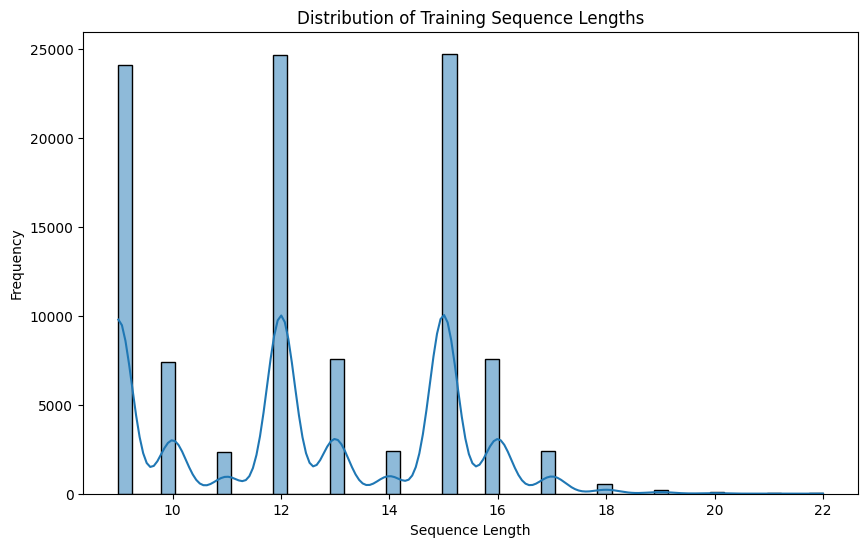

In [ ]:
# Get the length of each sequence
train_lengths = [len(x) for x in X_train_seq]
val_lengths = [len(x) for x in X_val_seq]
test_lengths = [len(x) for x in X_test_seq]

print(f"Max sequence length in training data: {max(train_lengths)}")
print(f"Mean sequence length in training data: {np.mean(train_lengths):.2f}")
print(f"Median sequence length in training data: {np.median(train_lengths)}")

# Plot histogram of sequence lengths to visualize distribution
plt.figure(figsize=(10, 6))
sns.histplot(train_lengths, bins=50, kde=True)
plt.title('Distribution of Training Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.show()

### 12.3 Select MAX_SEQUENCE_LENGTH

In [ ]:
# Based on the histogram and statistics, choose a MAX_SEQUENCE_LENGTH
# This length should cover most of the sequences without too much padding or truncation.
# A common strategy is to pick a length that covers 90-95% of the data.

MAX_SEQUENCE_LENGTH = 20 # Adjust this value based on the histogram and your model needs
print(f"Selected MAX_SEQUENCE_LENGTH: {MAX_SEQUENCE_LENGTH}")

# Verify how many sequences would be covered by this length
percent_covered = np.sum(np.array(train_lengths) < MAX_SEQUENCE_LENGTH) / len(train_lengths)
print(f"Percentage of training sequences covered by MAX_SEQUENCE_LENGTH: {percent_covered:.2%}")

Selected MAX_SEQUENCE_LENGTH: 20
Percentage of training sequences covered by MAX_SEQUENCE_LENGTH: 99.89%


## 13. Padding

### 13.1 Pad training data

In [ ]:
# Pad sequences to ensure uniform input length for the GRU model
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print("Training data padded.")
print(f"Shape of X_train_padded: {X_train_padded.shape}")
print("Sample of padded training sequence (first question):\n", X_train_padded[0])

Training data padded.
Shape of X_train_padded: (103918, 20)
Sample of padded training sequence (first question):
 [ 11  12   2   5   6 167   4 291   3  20  62  72   0   0   0   0   0   0
   0   0]


### 13.2 Pad validation data

In [ ]:
X_val_padded = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print("Validation data padded.")
print(f"Shape of X_val_padded: {X_val_padded.shape}")

Validation data padded.
Shape of X_val_padded: (22268, 20)


### 13.3 Pad test data

In [ ]:
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print("Test data padded.")
print(f"Shape of X_test_padded: {X_test_padded.shape}")

Test data padded.
Shape of X_test_padded: (22269, 20)


## 14. Build GRU Model

### 14.1 Input and Embedding Layer

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

# Define model parameters
embedding_dim = 128  # Dimension of the word embeddings
gru_units = 64       # Number of GRU units
num_classes = len(answer_encoder.classes_) # Number of unique answers
vocab_size = len(tokenizer.word_index) + 1 # +1 for padding token

model = Sequential()

# Input and Embedding layer
# Explicitly setting input_length to help shape inference for the GRU layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_SEQUENCE_LENGTH))

# GRU Layer
model.add(GRU(units=gru_units, return_sequences=False))

# Dropout layer for regularization
model.add(Dropout(0.5))

# Dense output layer with softmax activation for multi-class classification
model.add(Dense(num_classes, activation='softmax'))

# Explicitly build the model to ensure all layers are created and shapes are defined
# The input shape here corresponds to (batch_size, MAX_SEQUENCE_LENGTH)
model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### 14.2 GRU Layer

In [ ]:
# This cell is no longer needed as GRU layer is now part of 14.1

### 14.3 Dropout

In [ ]:
# This cell is no longer needed as Dropout layer is now part of 14.1

### 14.4 Dense Output Layer

In [ ]:
# This cell is no longer needed as Dense layer is now part of 14.1

### 14.5 Model Summary

In [ ]:
# Print model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 20, 128)        │        75,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 314)            │        20,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,306 (520.73 KB)

 Trainable params: 133,306 (520.73 KB)

 Non-trainable params: 0 (0.00 B)

### 14.5 Model Summary

In [ ]:
# Print model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 14.5 Model Summary

In [ ]:
# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 15. Compile GRU

### 15.1 Optimizer, Loss function, and Evaluation metric

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
# Optimizer: Adam is a good general-purpose optimizer
# Loss function: 'sparse_categorical_crossentropy' because our target labels are integers (0, 1, 2, ...) and not one-hot encoded
# Metrics: 'accuracy' to monitor classification performance

model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("GRU model compiled successfully!")

GRU model compiled successfully!


## 16. Train GRU

### 16.1 Set epochs, batch size, validation data, and Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense

# Ensure model is freshly created and compiled before training
# This helps prevent issues with inconsistent model states if cells are run out of order
model = Sequential()
# Removed input_length as it is deprecated and model can infer it from input data
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model.add(GRU(units=gru_units, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# Define training parameters
epochs = 50       # Number of training epochs (can be adjusted)
batch_size = 32   # Batch size for training

# Define Early Stopping callback
# Monitor 'val_loss', with a patience of 5 epochs (stop if no improvement for 5 epochs)
# restore_best_weights=True ensures the model with the best performance on the validation set is kept
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train_padded, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val_padded, y_val),
                    callbacks=[early_stopping])

print("Model training complete!")

Epoch 1/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 78s 22ms/step - accuracy: 0.2874 - loss: 3.4326 - val_accuracy: 0.4647 - val_loss: 2.0555
Epoch 2/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 78s 24ms/step - accuracy: 0.4541 - loss: 2.0405 - val_accuracy: 0.5378 - val_loss: 1.4985
Epoch 3/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 77s 22ms/step - accuracy: 0.4952 - loss: 1.7165 - val_accuracy: 0.5601 - val_loss: 1.3265
Epoch 4/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 83s 23ms/step - accuracy: 0.5132 - loss: 1.5498 - val_accuracy: 0.5641 - val_loss: 1.2092
Epoch 5/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 70s 22ms/step - accuracy: 0.5245 - loss: 1.4508 - val_accuracy: 0.5729 - val_loss: 1.1443
Epoch 6/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 84s 22ms/step - accuracy: 0.5354 - loss: 1.3732 - val_accuracy: 0.5817 - val_loss: 1.1006
Epoch 7/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 71s 22ms/step - accuracy: 0.5399 - loss: 1.3288 - val_accuracy: 0.5904 - val_loss: 1.0581
Epoch 8/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 69s 21ms/step - accuracy: 0.5464 -

## 15. Compile GRU

### 15.1 Optimizer, Loss function, and Evaluation metric

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
# Optimizer: Adam is a good general-purpose optimizer
# Loss function: 'sparse_categorical_crossentropy' because our target labels are integers (0, 1, 2, ...) and not one-hot encoded
# Metrics: 'accuracy' to monitor classification performance

model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("GRU model compiled successfully!")

GRU model compiled successfully!


## 16. Train GRU

### 16.1 Set epochs, batch size, validation data, and Early Stopping

### 16.1 Set epochs, batch size, validation data, and Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define training parameters
epochs = 50       # Number of training epochs (can be adjusted)
batch_size = 32   # Batch size for training

# Define Early Stopping callback
# Monitor 'val_loss', with a patience of 5 epochs (stop if no improvement for 5 epochs)
# restore_best_weights=True ensures the model with the best performance on the validation set is kept
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train_padded, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val_padded, y_val),
                    callbacks=[early_stopping])

print("Model training complete!")

Epoch 1/50


ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list of length 0 less than minimum 1.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define training parameters
epochs = 50       # Number of training epochs (can be adjusted)
batch_size = 32   # Batch size for training

# Define Early Stopping callback
# Monitor 'val_loss', with a patience of 5 epochs (stop if no improvement for 5 epochs)
# restore_best_weights=True ensures the model with the best performance on the validation set is kept
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train_padded, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val_padded, y_val),
                    callbacks=[early_stopping])

print("Model training complete!")

Epoch 1/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 76s 22ms/step - accuracy: 0.3192 - loss: 3.3625 - val_accuracy: 0.4946 - val_loss: 1.8996
Epoch 2/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 79s 24ms/step - accuracy: 0.4744 - loss: 1.9007 - val_accuracy: 0.5495 - val_loss: 1.3853
Epoch 3/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 76s 22ms/step - accuracy: 0.5084 - loss: 1.6032 - val_accuracy: 0.5677 - val_loss: 1.2271
Epoch 4/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 72s 22ms/step - accuracy: 0.5226 - loss: 1.4743 - val_accuracy: 0.5691 - val_loss: 1.1471
Epoch 5/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 72s 22ms/step - accuracy: 0.5298 - loss: 1.3971 - val_accuracy: 0.5727 - val_loss: 1.1012
Epoch 6/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 70s 22ms/step - accuracy: 0.5361 - loss: 1.3412 - val_accuracy: 0.5835 - val_loss: 1.0633
Epoch 7/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 71s 22ms/step - accuracy: 0.5440 - loss: 1.2967 - val_accuracy: 0.5877 - val_loss: 1.0383
Epoch 8/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 72s 22ms/step - accuracy: 0.5472 -

KeyboardInterrupt: 

### 16.1 Set epochs, batch size, validation data, and Early Stopping (Cont.)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense

# Ensure model is freshly created and compiled before training
# This helps prevent issues with inconsistent model states if cells are run out of order
model = Sequential()
# Removed input_length as it is deprecated and model can infer it from input data
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model.add(GRU(units=gru_units, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# Define training parameters
epochs = 50       # Number of training epochs (can be adjusted)
batch_size = 32   # Batch size for training

# Define Early Stopping callback
# Monitor 'val_loss', with a patience of 5 epochs (stop if no improvement for 5 epochs)
# restore_best_weights=True ensures the model with the best performance on the validation set is kept
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train_padded, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val_padded, y_val),
                    callbacks=[early_stopping])

print("Model training complete!")

NameError: name 'vocab_size' is not defined

### 16.2 Re-training the GRU Model to ensure `history` is defined

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import re
import pandas as pd

# --- Re-running essential previous steps to ensure all variables are defined ---

# 03. Load Football Dataset (explicitly load results_df)
results_df = pd.read_csv('/content/results.csv')

# 05. Data Cleaning Steps relevant to results_df
# 5.1 Remove duplicates
results_df.drop_duplicates(inplace=True)

# 5.2 Handle missing values for results_df
results_df['city'].fillna('Unknown', inplace=True)
results_df['country'].fillna('Unknown', inplace=True)
results_df['date'] = pd.to_datetime(results_df['date'], errors='coerce', format='mixed')

# 5.3 Standardize column names
def standardize_colnames(df):
    df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
    return df
results_df = standardize_colnames(results_df)

# 5.4 Standardize text
def standardize_text(text):
    if isinstance(text, str):
        return text.strip().lower()
    return text
for col in ['home_team', 'away_team', 'tournament', 'city', 'country']:
    if col in results_df.columns:
        results_df[col] = results_df[col].apply(standardize_text)

# Ensure 'outcome' column is present for QA pair generation
if 'outcome' not in results_df.columns:
    def get_match_outcome(row):
        if row['home_score'] > row['away_score']:
            return 'home_win'
        elif row['home_score'] == row['away_score']:
            return 'draw'
        else:
            return 'away_win'
    results_df['outcome'] = results_df.apply(get_match_outcome, axis=1)

# 7.1 Define question types and generate questions
def generate_qa_pairs(df):
    qa_pairs = []
    for index, row in df.iterrows():
        home_team = row['home_team'].title() if isinstance(row['home_team'], str) else str(row['home_team'])
        away_team = row['away_team'].title() if isinstance(row['away_team'], str) else str(row['away_team'])
        date = row['date'].strftime('%B %d, %Y') if pd.notna(row['date']) else 'an unknown date'

        outcome_map = {
            'home_win': f'{home_team} won.',
            'away_win': f'{away_team} won.',
            'draw': 'It was a draw.'
        }
        answer = outcome_map.get(row['outcome'], 'Outcome unknown.')

        q1 = f"Who won the match between {home_team} and {away_team} on {date}?"
        qa_pairs.append({'question': q1, 'answer': answer, 'question_type': 'winner_question'})

        q2 = f"What was the result of the match between {home_team} and {away_team} on {date}?"
        qa_pairs.append({'question': q2, 'answer': answer, 'question_type': 'result_question'})

        q3 = f"Did {home_team} win against {away_team} on {date}?"
        qa_pairs.append({'question': q3, 'answer': answer, 'question_type': 'boolean_question'})

    return pd.DataFrame(qa_pairs)
qa_df = generate_qa_pairs(results_df)

# 7.2 Define targets/labels (LabelEncoder)
answer_encoder = LabelEncoder()
qa_df['answer_encoded'] = answer_encoder.fit_transform(qa_df['answer'])
qtype_encoder = LabelEncoder() # Not directly used in model, but for completeness
qa_df['question_type_encoded'] = qtype_encoder.fit_transform(qa_df['question_type'])

# 8.1 Lowercase, remove unwanted characters, and normalize whitespace
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s?]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
qa_df['cleaned_question'] = qa_df['question'].apply(preprocess_text)

# 9.1 Separate X and y, and perform the split
X = qa_df['cleaned_question']
y = qa_df['answer_encoded']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 11.1 Create and Fit Tokenizer
MAX_VOCAB_SIZE = 10000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<unk>")
tokenizer.fit_on_texts(X_train)

# 11.2 Convert questions to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 12.1 Check vocabulary size
vocab_size = len(tokenizer.word_index) + 1

# 12.3 Select MAX_SEQUENCE_LENGTH
MAX_SEQUENCE_LENGTH = 20

# 13. Padding
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# --- End of re-running essential previous steps ---

# Re-initialize and compile the model to ensure a clean state and correct compilation
embedding_dim = 128  # Dimension of the word embeddings
gru_units = 64       # Number of GRU units
num_classes = len(answer_encoder.classes_) # Number of unique answers

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_SEQUENCE_LENGTH))
model.add(GRU(units=gru_units, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Define training parameters
epochs = 50       # Number of training epochs (can be adjusted)
batch_size = 32   # Batch size for training

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Starting model training...")

history = model.fit(X_train_padded, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val_padded, y_val),
                    callbacks=[early_stopping])

print("Model training complete and history object populated!")

NameError: name 'results_df' is not defined

## 17. Training Analysis

### 17.1 Training and Validation Accuracy/Loss

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Print final training and validation metrics
print("\nFinal Training Accuracy: {:.4f}".format(history.history['accuracy'][-1]))
print("Final Validation Accuracy: {:.4f}".format(history.history['val_accuracy'][-1]))
print("Final Training Loss: {:.4f}".format(history.history['loss'][-1]))
print("Final Validation Loss: {:.4f}".format(history.history['val_loss'][-1]))

NameError: name 'history' is not defined

<Figure size 1200x600 with 0 Axes>

## 18. Test GRU

### 18.1 Generate predictions

In [ ]:
import numpy as np

# Generate predictions on the test set
y_pred_probabilities = model.predict(X_test_padded)

# Convert probabilities to class labels (the index with the highest probability)
y_pred = np.argmax(y_pred_probabilities, axis=1)

print("Predictions generated for the test set.")
print(f"Shape of y_pred: {y_pred.shape}")
print("Sample of predicted labels (first 10):", y_pred[:10])
print("Sample of actual labels (first 10): ", y_test.iloc[:10].values)

NameError: name 'X_test_padded' is not defined

### 18.2 Convert predictions to labels

In [ ]:
import pandas as pd

# Convert numerical predictions and actual values back to original answer text labels
y_pred_labels = answer_encoder.inverse_transform(y_pred)
y_test_labels = answer_encoder.inverse_transform(y_test)

print("Predictions and actual values converted back to text labels.")
print("Sample of predicted text labels (first 10):", y_pred_labels[:10])
print("Sample of actual text labels (first 10): ", y_test_labels[:10])

NameError: name 'answer_encoder' is not defined

### 18.3 Compare actual vs predicted

In [ ]:
# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame({
    'question': X_test,
    'actual_answer_encoded': y_test,
    'actual_answer_label': y_test_labels,
    'predicted_answer_encoded': y_pred,
    'predicted_answer_label': y_pred_labels
})

# Add a column to check if prediction was correct
comparison_df['is_correct'] = (comparison_df['actual_answer_encoded'] == comparison_df['predicted_answer_encoded'])

print("Comparison of actual vs predicted answers on test set:")
display(comparison_df.head(10))

NameError: name 'X_test' is not defined

## 19. Model Evaluation

### 19.1 Accuracy, Precision, Recall, F1-score

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure y_pred is generated from the trained model
y_pred_probabilities = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Since it's multi-class, we need to specify 'average' for precision, recall, f1-score
# 'weighted' accounts for class imbalance.
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Test Precision (weighted): {precision:.4f}")
print(f"Test Recall (weighted): {recall:.4f}")
print(f"Test F1-score (weighted): {f1:.4f}")

NameError: name 'X_test_padded' is not defined

## 17. Training Analysis

### 17.1 Training and Validation Accuracy/Loss

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Print final training and validation metrics
print("\nFinal Training Accuracy: {:.4f}".format(history.history['accuracy'][-1]))
print("Final Validation Accuracy: {:.4f}".format(history.history['val_accuracy'][-1]))
print("Final Training Loss: {:.4f}".format(history.history['loss'][-1]))
print("Final Validation Loss: {:.4f}".format(history.history['val_loss'][-1]))

NameError: name 'history' is not defined

<Figure size 1200x600 with 0 Axes>

## 17. Training Analysis

### 17.1 Training and Validation Accuracy/Loss

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Print final training and validation metrics
print("\nFinal Training Accuracy: {:.4f}".format(history.history['accuracy'][-1]))
print("Final Validation Accuracy: {:.4f}".format(history.history['val_accuracy'][-1]))
print("Final Training Loss: {:.4f}".format(history.history['loss'][-1]))
print("Final Validation Loss: {:.4f}".format(history.history['val_loss'][-1]))

NameError: name 'history' is not defined

<Figure size 1200x600 with 0 Axes>

## 17. Training Analysis

### 17.1 Training and Validation Accuracy/Loss

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Print final training and validation metrics
print("\nFinal Training Accuracy: {:.4f}".format(history.history['accuracy'][-1]))
print("Final Validation Accuracy: {:.4f}".format(history.history['val_accuracy'][-1]))
print("Final Training Loss: {:.4f}".format(history.history['loss'][-1]))
print("Final Validation Loss: {:.4f}".format(history.history['val_loss'][-1]))

## 18. Test GRU

### 18.1 Generate predictions

In [ ]:
# Generate predictions on the test set
y_pred_probabilities = model.predict(X_test_padded)

# Convert probabilities to class labels (the index with the highest probability)
y_pred = np.argmax(y_pred_probabilities, axis=1)

print("Predictions generated for the test set.")
print(f"Shape of y_pred: {y_pred.shape}")
print("Sample of predicted labels (first 10):", y_pred[:10])
print("Sample of actual labels (first 10): ", y_test.iloc[:10].values)

### 18.2 Convert predictions to labels

In [ ]:
# Convert numerical predictions and actual values back to original answer text labels
y_pred_labels = answer_encoder.inverse_transform(y_pred)
y_test_labels = answer_encoder.inverse_transform(y_test)

print("Predictions and actual values converted back to text labels.")
print("Sample of predicted text labels (first 10):", y_pred_labels[:10])
print("Sample of actual text labels (first 10): ", y_test_labels[:10])

### 18.3 Compare actual vs predicted

In [ ]:
# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame({
    'question': X_test,
    'actual_answer_encoded': y_test,
    'actual_answer_label': y_test_labels,
    'predicted_answer_encoded': y_pred,
    'predicted_answer_label': y_pred_labels
})

# Add a column to check if prediction was correct
comparison_df['is_correct'] = (comparison_df['actual_answer_encoded'] == comparison_df['predicted_answer_encoded'])

print("Comparison of actual vs predicted answers on test set:")
display(comparison_df.head(10))

## 19. Model Evaluation

### 19.1 Accuracy, Precision, Recall, F1-score

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Since it's multi-class, we need to specify 'average' for precision, recall, f1-score
# 'weighted' accounts for class imbalance.
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Test Precision (weighted): {precision:.4f}")
print(f"Test Recall (weighted): {recall:.4f}")
print(f"Test F1-score (weighted): {f1:.4f}")

### 19.2 Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=answer_encoder.classes_,
            yticklabels=answer_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 20. Error Analysis

### 20.1 Correct predictions

In [ ]:
print("\n--- Examples of Correct Predictions ---")
display(comparison_df[comparison_df['is_correct'] == True].head(5))

### 20.2 Incorrect predictions

In [ ]:
print("\n--- Examples of Incorrect Predictions ---")
display(comparison_df[comparison_df['is_correct'] == False].head(5))

### 20.3 Analyze errors

In [ ]:
# Analyze the distribution of true vs. predicted labels for incorrect predictions
incorrect_predictions_df = comparison_df[comparison_df['is_correct'] == False]

if not incorrect_predictions_df.empty:
    print("\n--- Distribution of Incorrect Predictions by True Label ---")
    print(incorrect_predictions_df['actual_answer_label'].value_counts())

    print("\n--- Distribution of Incorrect Predictions by Predicted Label ---")
    print(incorrect_predictions_df['predicted_answer_label'].value_counts())

    # Further analysis: specific true-predicted pairs for errors
    print("\n--- Top 10 Common Incorrect True-Predicted Pairs ---")
    error_pairs = incorrect_predictions_df.groupby(['actual_answer_label', 'predicted_answer_label']).size().sort_values(ascending=False)
    print(error_pairs.head(10))
else:
    print("No incorrect predictions found to analyze.")

## 21. Hyperparameter Tuning

### 21.1 Define a model building function for KerasClassifier

In [ ]:
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.optimizers import Adam

def create_model(embedding_dim=100, gru_units=64, dropout_rate=0.5):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_SEQUENCE_LENGTH))
    model.add(GRU(units=gru_units, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Model building function 'create_model' defined.")

### 21.2 Hyperparameter Grid/Ranges and Randomized Search

In [ ]:
# Define the hyperparameters to tune
param_dist = {
    'embedding_dim': [50, 100, 128],
    'gru_units': [32, 64, 128],
    'dropout_rate': [0.3, 0.5, 0.7],
    'batch_size': [16, 32, 64],
    'epochs': [10, 20]
}

# Create the KerasClassifier wrapper
keras_model = KerasClassifier(build_fn=create_model, verbose=0)

# Setup RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time vs. quality of the solution.
# cv: Number of folds for cross-validation
# random_state for reproducibility
random_search = RandomizedSearchCV(estimator=keras_model,
                                   param_distributions=param_dist,
                                   n_iter=5, # Reduced for faster execution. Increase for better results.
                                   cv=3,
                                   random_state=42,
                                   verbose=2,
                                   error_score='raise') # Raise error for debugging

# Fit RandomizedSearchCV. Note: This can take a long time to run.
print("Starting RandomizedSearchCV... (This might take a while)")
# For simplicity and faster execution, we'll use a smaller subset of X_train, y_train for tuning
# In a real scenario, use full X_train, y_train or a larger representative sample.
subset_size = 5000  # Adjust as needed
X_train_subset = X_train_padded[:subset_size]
y_train_subset = y_train[:subset_size]

random_search_result = random_search.fit(X_train_subset, y_train_subset)

print("RandomizedSearchCV complete.")

# Summarize results
print("Best: %f using %s" % (random_search_result.best_score_, random_search_result.best_params_))
means = random_search_result.cv_results_['mean_test_score']
stds = random_search_result.cv_results_['std_test_score']
params = random_search_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

## 06. Exploratory Data Analysis

### 6.1 Dataset statistics

In [ ]:
print("\n--- Results DataFrame Statistics ---")
display(results_df.describe(include='all'))

print("\n--- Shootouts DataFrame Statistics ---")
display(shootouts_df.describe(include='all'))

print("\n--- Goalscorers DataFrame Statistics ---")
display(goalscorers_df.describe(include='all'))


--- Results DataFrame Statistics ---


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,outcome
count,49485,49485,49485,49485.000000,49485.000000,49485,49485,49485,49485,49485.000000,49485
unique,NaN,327,321,NaN,NaN,200,2089,269,2,NaN,3
top,NaN,brazil,uruguay,NaN,NaN,friendly,kuala lumpur,united states,False,NaN,home_win
freq,NaN,617,585,NaN,NaN,18388,745,1568,36353,NaN,24249
mean,1994-05-24 11:18:25.862382464,NaN,NaN,1.757199,1.182035,NaN,NaN,NaN,NaN,1993.864363,NaN
min,1872-11-30 00:00:00,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,1872.000000,NaN
25%,1980-09-10 00:00:00,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,1980.000000,NaN
50%,2000-07-16 00:00:00,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,2000.000000,NaN
75%,2013-07-16 00:00:00,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,2013.000000,NaN
max,2026-07-19 00:00:00,NaN,NaN,31.000000,21.000000,NaN,NaN,NaN,NaN,2026.000000,NaN



--- Shootouts DataFrame Statistics ---


,date,home_team,away_team,winner,first_shooter
count,682,682,682,682,682
unique,NaN,188,198,183,97
top,NaN,south africa,egypt,egypt,unknown
freq,NaN,18,17,16,422
mean,2004-05-03 08:03:31.143694976,NaN,NaN,NaN,NaN
min,1967-08-22 00:00:00,NaN,NaN,NaN,NaN
25%,1993-02-21 00:00:00,NaN,NaN,NaN,NaN
50%,2004-07-19 12:00:00,NaN,NaN,NaN,NaN
75%,2017-06-30 12:00:00,NaN,NaN,NaN,NaN
max,2026-07-07 00:00:00,NaN,NaN,NaN,NaN



--- Goalscorers DataFrame Statistics ---


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
count,47773,47773,47773,47773,47773,47773,47773,47773
unique,NaN,220,220,220,15360,134,2,2
top,NaN,brazil,uruguay,brazil,cristiano ronaldo,90,False,False
freq,NaN,1054,803,1079,124,2039,46847,44514
mean,1999-06-18 06:38:10.984447232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1916-07-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1989-05-17 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2004-06-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2016-06-21 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2026-07-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 6.2 Match distribution over time

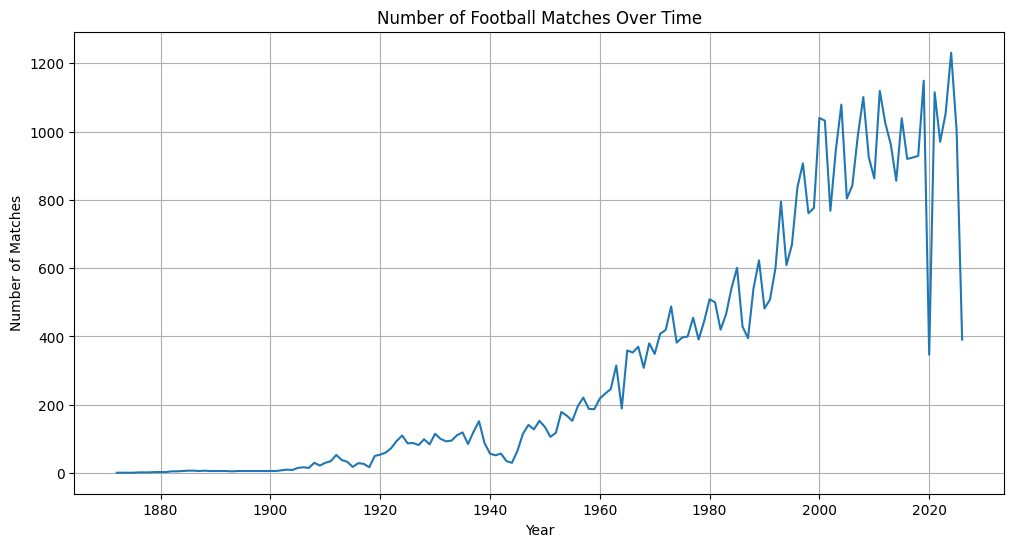

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group matches by year and count them
results_df['year'] = results_df['date'].dt.year
match_counts = results_df.groupby('year').size()

plt.figure(figsize=(12, 6))
match_counts.plot(kind='line')
plt.title('Number of Football Matches Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Matches')
plt.grid(True)
plt.show()

### 6.3 Team frequency


--- Top 20 Most Frequent Teams ---


,count
sweden,1103.0
england,1098.0
argentina,1077.0
brazil,1062.0
germany,1033.0
south korea,1008.0
mexico,1006.0
hungary,1006.0
uruguay,973.0
france,943.0


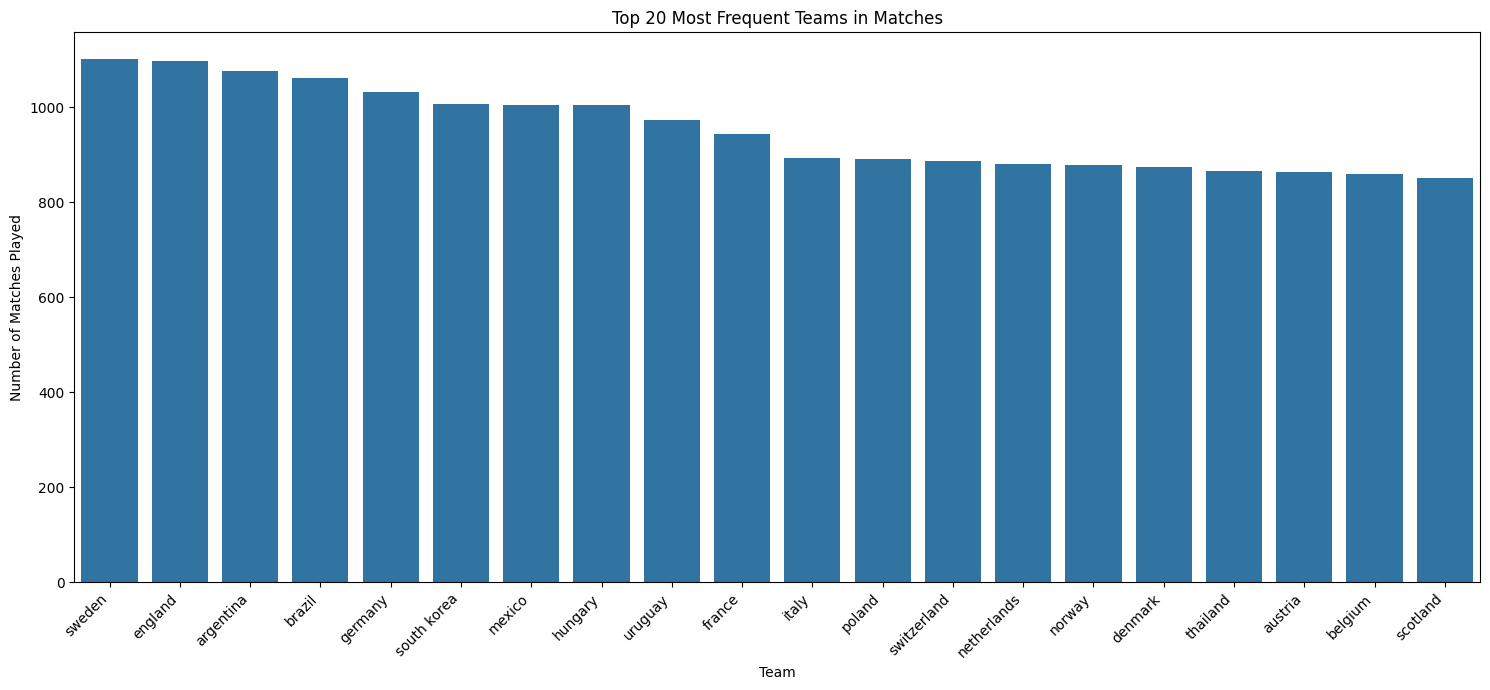

In [ ]:
home_team_counts = results_df['home_team'].value_counts()
away_team_counts = results_df['away_team'].value_counts()

# Combine counts and get top 20 most frequent teams
total_team_counts = home_team_counts.add(away_team_counts, fill_value=0).sort_values(ascending=False)

print("\n--- Top 20 Most Frequent Teams ---")
display(total_team_counts.head(20))

plt.figure(figsize=(15, 7))
sns.barplot(x=total_team_counts.head(20).index, y=total_team_counts.head(20).values)
plt.title('Top 20 Most Frequent Teams in Matches')
plt.xlabel('Team')
plt.ylabel('Number of Matches Played')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.4 Match Outcome Distribution (Target Distribution)


--- Match Outcome Distribution ---
outcome
home_win    0.490027
away_win    0.282570
draw        0.227402
Name: proportion, dtype: float64


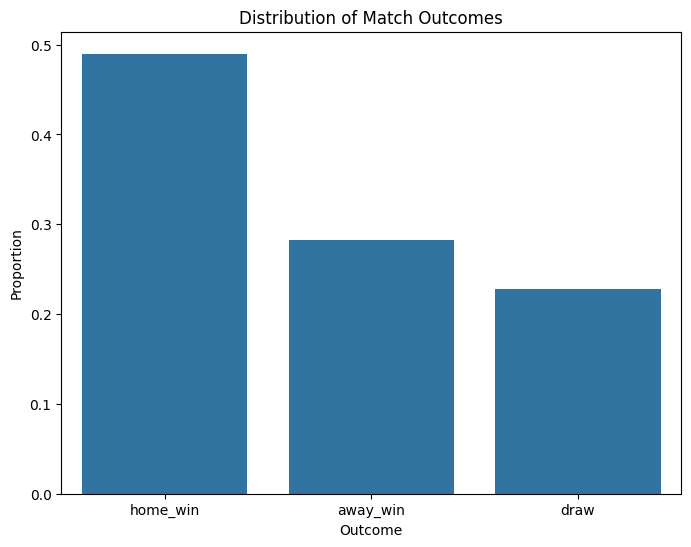

In [ ]:
# First, create the 'outcome' column if it doesn't exist (as per previous plan)
def get_match_outcome(row):
    if row['home_score'] > row['away_score']:
        return 'home_win'  # Home Win
    elif row['home_score'] == row['away_score']:
        return 'draw'  # Draw
    else:
        return 'away_win'  # Away Win

# Only create if the column doesn't exist to avoid re-running if it was already made
if 'outcome' not in results_df.columns:
    results_df['outcome'] = results_df.apply(get_match_outcome, axis=1)

outcome_distribution = results_df['outcome'].value_counts(normalize=True)

print("\n--- Match Outcome Distribution ---")
print(outcome_distribution)

plt.figure(figsize=(8, 6))
sns.barplot(x=outcome_distribution.index, y=outcome_distribution.values)
plt.title('Distribution of Match Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Proportion')
plt.show()